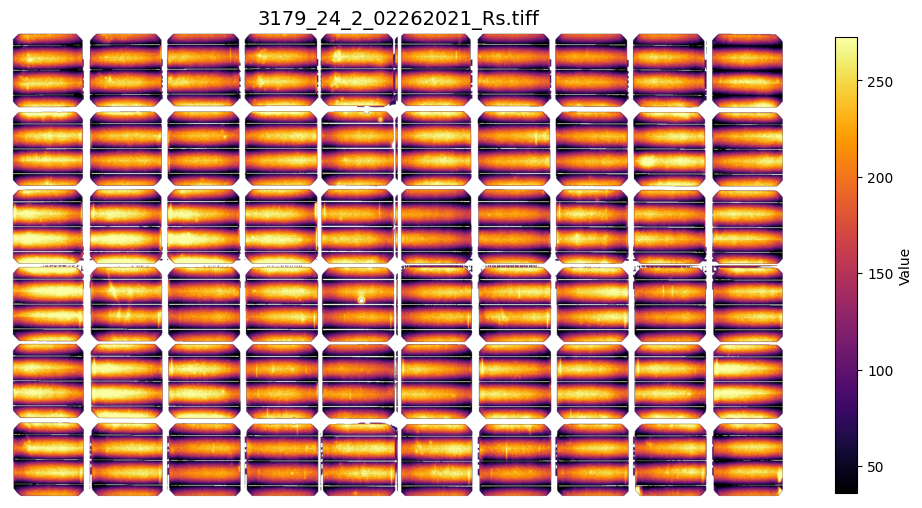

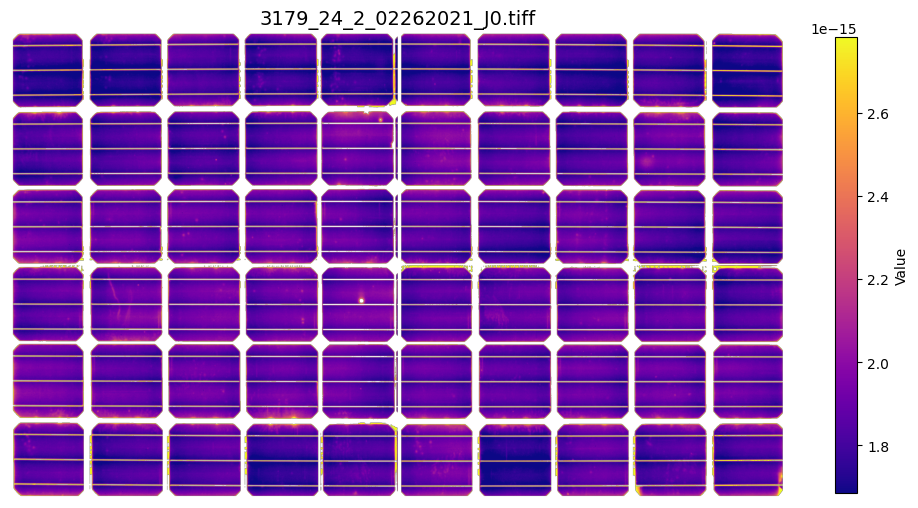

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

def display_map_tiff(path, cmap="inferno", p_low=2, p_high=98):
    """
    Load a .tiff map and display with colormap + colorbar.
    """
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        print(f"Cannot open: {path}")
        return

    img = img.astype(np.float64)

    # mask invalid
    valid = np.isfinite(img) & (img != 0)
    if valid.sum() == 0:
        print(f"No valid pixels in {path}")
        return

    # clip to percentile range
    vals = img[valid]
    lo, hi = np.percentile(vals, [p_low, p_high])
    img_disp = np.where(valid, np.clip(img, lo, hi), np.nan)

    name = os.path.basename(path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_disp, cmap=cmap, vmin=lo, vmax=hi)
    plt.colorbar(label="Value", shrink=0.8)
    plt.title(name, fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# --- single file ---
display_map_tiff(r"J0_Rs\3179_24_2_02262021_Rs.tiff", cmap="inferno")
display_map_tiff(r"J0_Rs\3179_24_2_02262021_J0.tiff", cmap="plasma")


# --- batch: display all Rs and J0 in a folder ---
def display_all_maps(folder, cmap_rs="inferno", cmap_j0="plasma"):
    files = sorted(glob.glob(os.path.join(folder, "*.tiff")))
    for f in files:
        name = os.path.basename(f).lower()
        if "_rs" in name:
            display_map_tiff(f, cmap=cmap_rs)
        elif "_j0" in name:
            display_map_tiff(f, cmap=cmap_j0)
        else:
            display_map_tiff(f, cmap="viridis")

display_all_maps(r"C:\...\your_maps_folder")

percell rows = 16440 | summary rows = 437


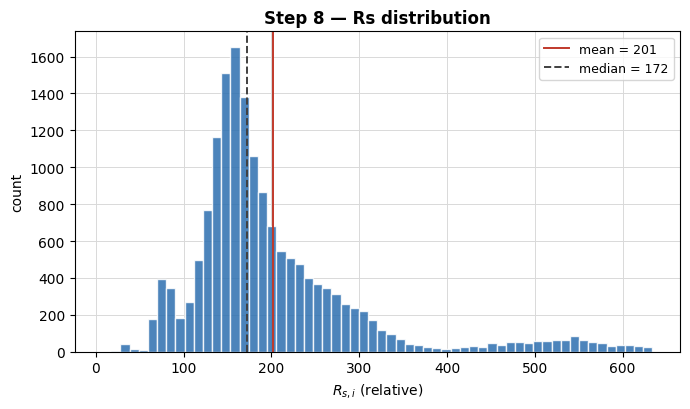

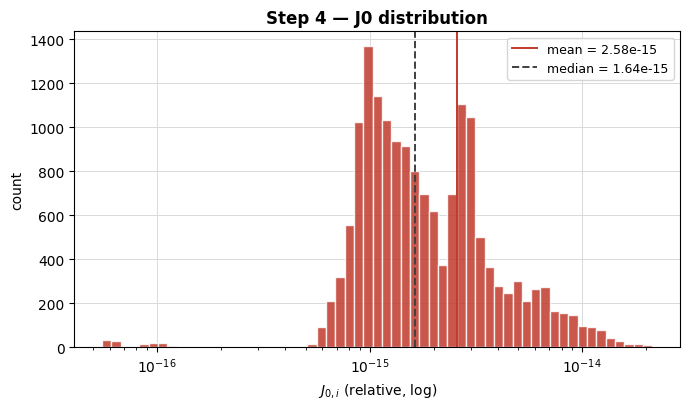

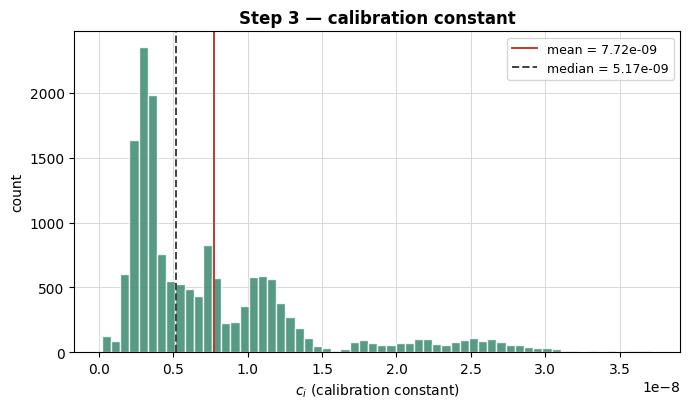

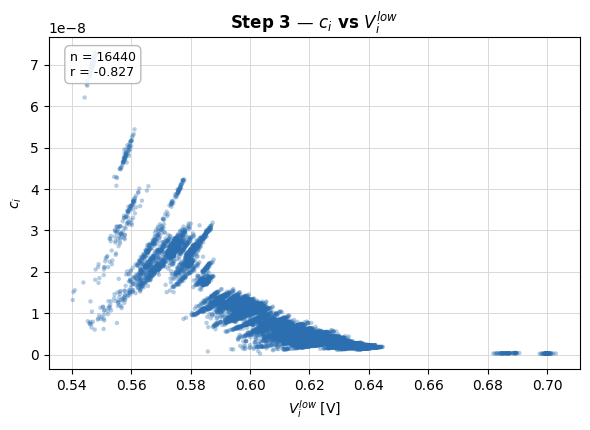

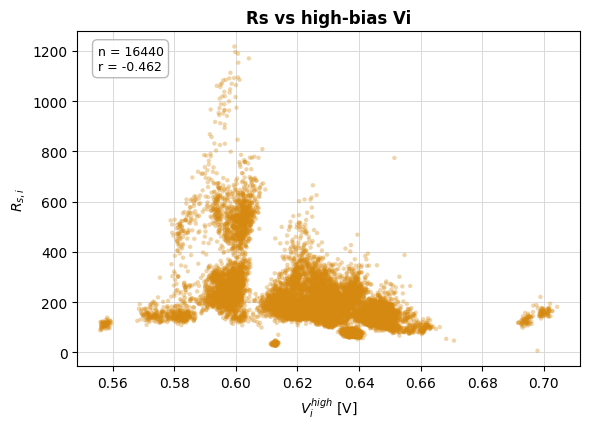

selesai -> C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\validation\plots


In [5]:
import os, csv
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = r"C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\validation"   # <-- ganti ke foldermu

def _read(path):
    if not os.path.exists(path): return []
    with open(path, newline="") as f:
        return list(csv.DictReader(f))

def _col(rows, k):
    v=[]
    for r in rows:
        try: v.append(float(r[k]))
        except (KeyError, ValueError, TypeError): v.append(np.nan)
    return np.array(v, float)

def make_plots(out_dir, show=True):
    pc  = _read(os.path.join(out_dir, "percell_values.csv"))      # per sel (utuh)
    val = _read(os.path.join(out_dir, "validation_summary.csv"))  # per modul (mungkin rusak)
    print(f"percell rows = {len(pc)} | summary rows = {len(val)}")
    if not pc:
        print("percell_values.csv kosong — tidak ada yang bisa diplot."); return

    pdir = os.path.join(out_dir, "plots"); os.makedirs(pdir, exist_ok=True)
    box = dict(boxstyle="round,pad=0.4", fc="white", ec="0.7", alpha=.9)

    def save(fig, name):
        fig.tight_layout(); fig.savefig(os.path.join(pdir, name), dpi=200, bbox_inches="tight")
        if show: plt.show()
        plt.close(fig)

    def hist(data, xl, title, name, color="#2c6fb0", logx=False):
        data = data[np.isfinite(data)]
        if logx: data = data[data > 0]
        if data.size == 0: print("skip", name, "(kosong)"); return
        fig, ax = plt.subplots(figsize=(7, 4.2))
        if logx:
            bins = np.logspace(np.log10(data.min()), np.log10(np.percentile(data,99.5)), 60)
            ax.set_xscale("log")
        else:
            data = data[data < np.percentile(data, 99)]; bins = 60
        ax.hist(data, bins=bins, color=color, alpha=.85, edgecolor="white")
        ax.axvline(np.mean(data),   color="#c0392b", lw=1.4, label=f"mean = {np.mean(data):.3g}")
        ax.axvline(np.median(data), color="0.25", lw=1.4, ls="--", label=f"median = {np.median(data):.3g}")
        ax.set_xlabel(xl); ax.set_ylabel("count"); ax.set_title(title, fontweight="bold")
        ax.grid(color="0.85", lw=.7, axis="both"); ax.set_axisbelow(True); ax.legend(fontsize=9)
        save(fig, name)

    def scatter(x, y, xl, yl, title, name, color="#2c6fb0"):
        m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
        if x.size == 0: print("skip", name, "(kosong)"); return
        fig, ax = plt.subplots(figsize=(6, 4.4))
        ax.scatter(x, y, s=10, c=color, alpha=.35, edgecolors="none")
        if np.unique(x).size > 1:
            r = np.corrcoef(x, y)[0, 1]
            ax.text(.04, .96, f"n = {x.size}\nr = {r:.3f}", transform=ax.transAxes,
                    va="top", fontsize=9, bbox=box)
        ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(title, fontweight="bold")
        ax.grid(color="0.85", lw=.7); ax.set_axisbelow(True)
        save(fig, name)

    # ---- dari percell_values.csv (pasti ada) ----
    hist(_col(pc, "Rs_i"),   "$R_{s,i}$ (relative)",          "Step 8 — Rs distribution",       "step8_Rs.png")
    hist(_col(pc, "J0_i"),   "$J_{0,i}$ (relative, log)",     "Step 4 — J0 distribution",       "step4_J0.png", color="#c0392b", logx=True)
    hist(_col(pc, "c_i"),    "$c_i$ (calibration constant)",  "Step 3 — calibration constant",  "step3_ci.png", color="#3a8a6e")
    scatter(_col(pc,"Vi_low"), _col(pc,"c_i"), "$V_i^{low}$ [V]", "$c_i$",
            "Step 3 — $c_i$ vs $V_i^{low}$", "step3_ci_vs_Vi.png")
    scatter(_col(pc,"Vi_high"), _col(pc,"Rs_i"), "$V_i^{high}$ [V]", "$R_{s,i}$",
            "Rs vs high-bias Vi", "Rs_vs_Vihigh.png", color="#d68910")

    print("selesai ->", pdir)

make_plots(OUT_DIR, show=True)

In [6]:
#!/usr/bin/env python3
r"""
visualize_validation.py
========================

Standalone visualisation for the Rajput EL validation pipeline. READS ONLY
from `percell_values.csv` and `validation_summary.csv` (produced by
validate_batch) — no cell images touched, no recomputation, safe to call
repeatedly and cheap to re-run after tweaking a plot.

Usage
-----
    from visualize_validation import visualize_all

    visualize_all(
        out_dir=r"C:\...\Coding\validation_v2",   # folder with the two CSVs
    )

Or call any single figure function directly, e.g. `plot_step5_step6(...)`.

Figures produced (same eight-step table)
-----------------------------------------
Step 2   identity residual histogram          sum(Vi_low) - VT_low
Step 3   c_i vs cell index (sample modules)    + c_i vs Vi_low hexbin
Step 4   J0 distribution across cells          (log scale)
Step 5   sum(Vi_high) vs measured VT_high      parity plot (independent test)
Step 6   sum(mean U) vs measured VT_high       parity plot
Step 7   reconstructed current / I_high        histogram
Step 8   Rs distribution across cells

Bonus (only if `make_model` column is present in validation_summary.csv)
Step 8b  Rs_module_total vs make_model         boxplot (population structure)
Step 4b  J0_module_mean vs make_model          boxplot
"""

from __future__ import annotations
import os
import csv
import numpy as np

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


# ============================================================ style
_STYLE = {
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.grid": True, "grid.color": "0.85", "grid.linewidth": 0.7,
    "axes.axisbelow": True, "axes.edgecolor": "0.4", "axes.linewidth": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "0.3", "ytick.color": "0.3",
    "legend.frameon": False, "figure.facecolor": "white",
}
_C = {"blue": "#2c6fb0", "red": "#c0392b", "green": "#3a8a6e", "amber": "#d68910"}
_BOX = dict(boxstyle="round,pad=0.4", fc="white", ec="0.7", alpha=0.9)


# ============================================================ IO
def _read_csv(path):
    if not os.path.exists(path):
        return []
    with open(path, newline="") as fh:
        return list(csv.DictReader(fh))


def _col(rows, key):
    out = []
    for r in rows:
        try:
            out.append(float(r.get(key, "nan")))
        except (ValueError, TypeError):
            out.append(np.nan)
    return np.array(out, dtype=float)


def load_validation_data(out_dir):
    """Load percell_values.csv and validation_summary.csv from out_dir."""
    pc = _read_csv(os.path.join(out_dir, "percell_values.csv"))
    val = _read_csv(os.path.join(out_dir, "validation_summary.csv"))
    val_ok = [v for v in val if v.get("status") == "ok"]
    print(f"[visualize_validation] percell rows = {len(pc)} | "
         f"module rows = {len(val)} (ok: {len(val_ok)})")
    return pc, val, val_ok


def _agreement(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y); x, y = x[ok], y[ok]
    out = {"n": int(x.size), "pearson": np.nan, "spearman": np.nan,
           "rmse": np.nan, "bias": np.nan}
    if x.size < 2:
        return out
    try:
        from scipy.stats import pearsonr, spearmanr
        out["pearson"] = float(pearsonr(x, y)[0])
        out["spearman"] = float(spearmanr(x, y)[0])
    except Exception:
        out["pearson"] = float(np.corrcoef(x, y)[0, 1])
        rx = np.argsort(np.argsort(x)); ry = np.argsort(np.argsort(y))
        out["spearman"] = float(np.corrcoef(rx, ry)[0, 1])
    out["rmse"] = float(np.sqrt(np.mean((y - x) ** 2)))
    out["bias"] = float(np.mean(y - x))
    return out


def _save(fig, plot_dir, name, show):
    os.makedirs(plot_dir, exist_ok=True)
    fig.tight_layout()
    fig.savefig(os.path.join(plot_dir, name))
    if show:
        plt.show()
    plt.close(fig)


# ============================================================ Step 2
def plot_step2(val_ok, plot_dir, show=True):
    if not val_ok:
        print("Step 2: no data"); return
    res = _col(val_ok, "step2_residual_V")
    with plt.rc_context(_STYLE):
        fig, ax = plt.subplots(figsize=(7, 4.2))
        ax.hist(res, bins=40, color=_C["blue"], alpha=0.85, edgecolor="white")
        ax.axvline(0, color=_C["red"], lw=1.3)
        ax.set_xlabel(r"$\sum_i V_i^{\mathrm{low}} - V_T^{\mathrm{low}}$  [V]")
        ax.set_ylabel("Number of modules")
        ax.set_title("Step 2 — Algebraic identity residual (expected 0)")
        mx = np.nanmax(np.abs(res)) if res.size else np.nan
        ax.text(0.03, 0.96, f"max |residual| = {mx:.2e} V", transform=ax.transAxes,
                va="top", fontsize=9, bbox=_BOX)
        ax.ticklabel_format(axis="x", style="sci", scilimits=(-2, 2))
        _save(fig, plot_dir, "step2_identity_residual.png", show)


# ============================================================ Step 3
def plot_step3(pc, plot_dir, show=True, n_sample_modules=4):
    if not pc:
        print("Step 3: no data"); return
    mods = sorted({r["module"] for r in pc})
    with plt.rc_context(_STYLE):
        fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
        palette = (_C["blue"], _C["amber"], _C["green"], _C["red"])
        for m, col in zip(mods[:n_sample_modules], palette):
            rows = [r for r in pc if r["module"] == m]
            ci = _col(rows, "c_i")
            ax[0].plot(_col(rows, "cell"), ci, "o-", ms=4, lw=0.8, color=col,
                       alpha=0.8, label=m)
            ax[0].axhline(np.nanmean(ci), color=col, lw=0.8, ls=":")
        ax[0].set_xlabel("Cell index"); ax[0].set_ylabel(r"$c_i$ (calibration constant)")
        ax[0].set_title("Step 3 — Per-cell calibration constant (cf. Fig. 4)")
        ax[0].legend(fontsize=8, ncol=2)

        vi = _col(pc, "Vi_low"); ci = _col(pc, "c_i")
        good = np.isfinite(vi) & np.isfinite(ci)
        hb = ax[1].hexbin(vi[good], ci[good], gridsize=40, cmap="Blues", mincnt=1)
        fig.colorbar(hb, ax=ax[1], label="cell count")
        ax[1].set_xlabel(r"$V_i^{\mathrm{low}}$  [V]"); ax[1].set_ylabel(r"$c_i$")
        ax[1].set_title(r"Step 3 — $c_i$ vs. $V_i^{\mathrm{low}}$ (all cells)")
        ax[1].grid(False)
        _save(fig, plot_dir, "step3_calibration_constant.png", show)


# ============================================================ Step 4 & 8
def plot_step4_step8(pc, plot_dir, show=True):
    if not pc:
        print("Step 4/8: no data"); return
    with plt.rc_context(_STYLE):
        fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

        rs = _col(pc, "Rs_i"); rs = rs[np.isfinite(rs)]
        if rs.size:
            rs_c = rs[rs < np.percentile(rs, 99)]
            ax[0].hist(rs_c, bins=60, color=_C["blue"], alpha=0.85, edgecolor="white")
            mean, med = np.mean(rs_c), np.median(rs_c)
            ax[0].axvline(mean, color=_C["red"], lw=1.4, label=f"mean = {mean:.3g}")
            ax[0].axvline(med, color="0.25", lw=1.4, ls="--", label=f"median = {med:.3g}")
            ax[0].legend(fontsize=8.5)
        ax[0].set_xlabel(r"$R_{s,i}$ (per cell, relative units)")
        ax[0].set_ylabel("Number of cells")
        ax[0].set_title("Step 8 — Series-resistance distribution (99th-pct clip)")

        j0 = _col(pc, "J0_i"); j0 = j0[np.isfinite(j0) & (j0 > 0)]
        if j0.size:
            bins = np.logspace(np.log10(j0.min()), np.log10(np.percentile(j0, 99.5)), 60)
            ax[1].hist(j0, bins=bins, color=_C["red"], alpha=0.85, edgecolor="white")
            ax[1].set_xscale("log")
            mean, med = np.mean(j0), np.median(j0)
            ax[1].axvline(mean, color=_C["red"], lw=1.4, label=f"mean = {mean:.3g}")
            ax[1].axvline(med, color="0.25", lw=1.4, ls="--", label=f"median = {med:.3g}")
            ax[1].legend(fontsize=8.5)
        ax[1].set_xlabel(r"$J_{0,i}$ (per cell, relative units, log scale)")
        ax[1].set_title("Step 4 — Dark-saturation-current distribution")
        _save(fig, plot_dir, "step4_8_Rs_J0_distributions.png", show)


# ============================================================ Step 5 & 6
def _parity(ax, x, y, xlabel, ylabel, color, title):
    x = np.asarray(x, float); y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y); x, y = x[ok], y[ok]
    ax.scatter(x, y, s=26, c=color, alpha=0.55, edgecolors="white", linewidths=0.5)
    if x.size:
        lo = min(x.min(), y.min()); hi = max(x.max(), y.max())
        pad = 0.03 * (hi - lo + 1e-12); lims = (lo - pad, hi + pad)
        ax.plot(lims, lims, "--", color="0.4", lw=1.2, label="identity (y = x)")
        ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal", "box")
    m = _agreement(x, y)
    txt = (f"n = {m['n']}\n$r$ = {m['pearson']:.3f}\n$\\rho$ = {m['spearman']:.3f}\n"
           f"RMSE = {m['rmse']:.3g}\nbias = {m['bias']:+.3g}")
    ax.text(0.04, 0.96, txt, transform=ax.transAxes, va="top", ha="left",
            fontsize=9, bbox=_BOX)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8.5)


def plot_step5(val_ok, plot_dir, show=True):
    x = _col(val_ok, "VT_high"); y = _col(val_ok, "step5_sum_Vi_high")
    if not np.isfinite(x).any():
        print("Step 5: no VT_high data — skipped"); return
    with plt.rc_context(_STYLE):
        fig, ax = plt.subplots(figsize=(5.6, 5.6))
        _parity(ax, x, y, r"Measured $V_T^{\mathrm{high}}$  [V]",
               r"Reconstructed $\sum_i V_i^{\mathrm{high}}$  [V]", _C["blue"],
               "Step 5 — Independent high-bias terminal-voltage test")
        _save(fig, plot_dir, "step5_VThigh_parity.png", show)


def plot_step6(val_ok, plot_dir, show=True):
    x = _col(val_ok, "VT_high"); y = _col(val_ok, "step6_sum_U_mean")
    if not np.isfinite(x).any():
        print("Step 6: no VT_high data — skipped"); return
    with plt.rc_context(_STYLE):
        fig, ax = plt.subplots(figsize=(5.6, 5.6))
        _parity(ax, x, y, r"Measured $V_T^{\mathrm{high}}$  [V]",
               r"$\sum_i \langle U \rangle_i$  [V]", _C["amber"],
               "Step 6 — Mean local voltage vs. terminal voltage")
        _save(fig, plot_dir, "step6_meanU_vs_VThigh.png", show)


# ============================================================ Step 7
def plot_step7(val_ok, plot_dir, show=True):
    ratio = _col(val_ok, "step7_ratio_to_I_high")
    ratio = ratio[np.isfinite(ratio)]
    if not ratio.size:
        print("Step 7: no data — skipped"); return
    with plt.rc_context(_STYLE):
        fig, ax = plt.subplots(figsize=(7, 4.2))
        ax.hist(ratio, bins=40, color=_C["green"], alpha=0.85, edgecolor="white")
        ax.axvline(1.0, color=_C["red"], lw=1.4, label="ideal ratio = 1")
        mean, med = np.mean(ratio), np.median(ratio)
        ax.axvline(mean, color="0.25", lw=1.2, ls="--", label=f"mean = {mean:.3g}")
        ax.set_xlabel(r"Reconstructed current / $I_{\mathrm{high}}$")
        ax.set_ylabel("Number of modules")
        ax.set_title("Step 7 — Reconstructed vs. injected high-bias current")
        ax.legend(fontsize=8.5)
        _save(fig, plot_dir, "step7_current_ratio.png", show)


# ============================================================ bonus: by make_model
def plot_by_make_model(val_ok, plot_dir, show=True, min_group_size=3):
    """Boxplots of module-level Rs/J0 grouped by make_model, IF that column
    exists in validation_summary.csv. Small groups (< min_group_size) are
    dropped since a boxplot on 1-2 points is not informative."""
    if not val_ok or "make_model" not in val_ok[0]:
        print("make_model grouping: column not present — skipped"); return
    from collections import defaultdict
    groups_rs, groups_j0 = defaultdict(list), defaultdict(list)
    for v in val_ok:
        mm = v.get("make_model", "").strip()
        if not mm:
            continue
        rs = float(v.get("step8_Rs_total", "nan") or "nan")
        j0 = float(v.get("step4_J0_mean", "nan") or "nan")
        if np.isfinite(rs):
            groups_rs[mm].append(rs)
        if np.isfinite(j0):
            groups_j0[mm].append(j0)

    def _box(groups, ylabel, title, fname, log_y=False):
        items = sorted(((k, v) for k, v in groups.items() if len(v) >= min_group_size),
                       key=lambda kv: np.median(kv[1]))
        if not items:
            print(f"{title}: no group has >= {min_group_size} modules — skipped")
            return
        labels = [f"{k}\n(n={len(v)})" for k, v in items]
        data = [v for _, v in items]
        with plt.rc_context(_STYLE):
            fig, ax = plt.subplots(figsize=(max(7, 0.6 * len(items) + 3), 4.8))
            bp = ax.boxplot(data, tick_labels=labels, patch_artist=True,
                            medianprops=dict(color=_C["red"], lw=1.6),
                            boxprops=dict(facecolor=_C["blue"], alpha=0.4))
            ax.set_ylabel(ylabel); ax.set_title(title)
            if log_y:
                ax.set_yscale("log")
            plt.xticks(rotation=45, ha="right", fontsize=8)
            _save(fig, plot_dir, fname, show)

    _box(groups_rs, r"$R_{s}^{\mathrm{module}}$ (relative)",
        "Rs by make_model (populous groups only)", "bonus_Rs_by_makemodel.png")
    _box(groups_j0, r"$J_{0}^{\mathrm{module}}$ (relative, log)",
        "J0 by make_model (populous groups only)", "bonus_J0_by_makemodel.png",
        log_y=True)


# ============================================================ orchestrator
def visualize_all(out_dir, show=False, min_group_size=3):
    """Run every plot from the CSVs already in out_dir. Read-only.

    show=False by default (safer for a big batch run); set True to also
    display inline in the notebook.
    """
    pc, val, val_ok = load_validation_data(out_dir)
    plot_dir = os.path.join(out_dir, "plots")

    plot_step2(val_ok, plot_dir, show)
    plot_step3(pc, plot_dir, show)
    plot_step4_step8(pc, plot_dir, show)
    plot_step5(val_ok, plot_dir, show)
    plot_step6(val_ok, plot_dir, show)
    plot_step7(val_ok, plot_dir, show)
    plot_by_make_model(val_ok, plot_dir, show, min_group_size=min_group_size)

    print(f"\n[visualize_validation] all figures -> {plot_dir}")

In [7]:
visualize_all(OUT_DIR, show=True, min_group_size=3)

[visualize_validation] percell rows = 16440 | module rows = 437 (ok: 274)


C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_3024\1171817364.py:114: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_3024\1171817364.py:114: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_3024\1171817364.py:114: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_3024\1171817364.py:114: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_3024\1171817364.py:114: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


make_model grouping: column not present — skipped

[visualize_validation] all figures -> C:\Users\Ghozy Abror\OneDrive - Institut Teknologi Bandung\Karirku\UNSW\Thesis\Coding\validation\plots


C:\Users\Ghozy Abror\AppData\Local\Temp\ipykernel_3024\1171817364.py:114: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
